# 07 PhoBERT Fine-tuning và PhoBERT + Metadata Hybrid Model

Notebook này thực hiện huấn luyện và đánh giá hai kiến trúc mô hình học sâu hiện đại:
1. **PhoBERT Fine-Tuning**: Tinh chỉnh mô hình pre-trained PhoBERT (`vinai/phobert-base`) cho bài toán phân loại cảm xúc.
2. **PhoBERT + Metadata (Hybrid)**: Kết hợp vector embedding của PhoBERT với đặc trưng metadata từ đánh giá (số sao `rating_stars` và biến nhị phân `has_media` tự định nghĩa) để đưa ra dự đoán.

## 0. Import Thư viện và Cấu hình Thiết bị

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from pathlib import Path

# Cấu hình đường dẫn
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "interim" / "df_lstm_segmented.csv"
MODEL_SAVE_DIR = PROJECT_ROOT / "models" / "phobert"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Chọn thiết bị tính toán
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


## 1. Chuẩn bị Dữ liệu

In [2]:
print(f"Đang đọc dữ liệu từ: {DATA_PATH.name}...")
df = pd.read_csv(DATA_PATH)

# Mã hóa nhãn cảm xúc
label_map = {"positive": 1, "negative": 0}
df["label_code"] = df["label"].map(label_map)

# Trích xuất trường metadata tự chế 'has_media' từ văn bản đánh giá
media_keywords = ["ảnh", "video", "hình", "clip", "media", "anh", "hinh"]
df["has_media"] = df["review"].astype(str).apply(lambda x: 1 if any(kw in x.lower() for kw in media_keywords) else 0)

# Chuẩn hóa rating_stars
df["rating_stars"] = df["rating"] / 5.0

print(f"Kích thước dữ liệu: {df.shape}")
print(df[["review", "rating_stars", "has_media", "label_code"]].head())

Đang đọc dữ liệu từ: df_lstm_segmented.csv...
Kích thước dữ liệu: (10947, 8)
                                              review  rating_stars  has_media  \
0  mùi hương:ngọt nhẹ, thomm phù hợp với loại da:...           0.8          1   
1  tôi rất hài lòng với dịch vụ của người bán và ...           1.0          1   
2  review nhẹ một số dòng sữa còn uống tăng cân t...           1.0          1   
3  hiệu quá:sạch thiết kế:đẹp thiết kế nhỏ gọn, t...           1.0          1   
4  giao hàng nhanh, đóng gói đẹp ăn toàn mùi pink...           0.8          1   

   label_code  
0           1  
1           1  
2           1  
3           1  
4           1  


## 2. Tokenize và Chuẩn bị DataLoader

In [3]:
# Tách dữ liệu
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label_code"])

print("Loading PhoBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

train_encodings = tokenizer(train_df["segmented_review"].astype(str).tolist(), padding="max_length", truncation=True, max_length=128)
test_encodings = tokenizer(test_df["segmented_review"].astype(str).tolist(), padding="max_length", truncation=True, max_length=128)

train_metadata = np.stack([train_df["rating_stars"].values, train_df["has_media"].values], axis=1)
test_metadata = np.stack([test_df["rating_stars"].values, test_df["has_media"].values], axis=1)

class PhoBertDataset(Dataset):
    def __init__(self, encodings, labels, metadata=None):
        self.encodings = encodings
        self.labels = labels
        self.metadata = metadata
        
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.metadata is not None:
            item["metadata"] = torch.tensor(self.metadata[idx], dtype=torch.float32)
        return item
        
    def __len__(self):
        return len(self.labels)

# Khởi tạo datasets & loaders
train_dataset_std = PhoBertDataset(train_encodings, train_df["label_code"].values)
test_dataset_std = PhoBertDataset(test_encodings, test_df["label_code"].values)

train_dataset_hyb = PhoBertDataset(train_encodings, train_df["label_code"].values, train_metadata)
test_dataset_hyb = PhoBertDataset(test_encodings, test_df["label_code"].values, test_metadata)

train_loader_std = DataLoader(train_dataset_std, batch_size=16, shuffle=True)
test_loader_std = DataLoader(test_dataset_std, batch_size=16, shuffle=False)

train_loader_hyb = DataLoader(train_dataset_hyb, batch_size=16, shuffle=True)
test_loader_hyb = DataLoader(test_dataset_hyb, batch_size=16, shuffle=False)

Loading PhoBERT tokenizer...


## 3. Định nghĩa Mô hình Lai (PhoBERT + Metadata)

In [4]:
class PhoBertWithMetadata(nn.Module):
    def __init__(self, model_name="vinai/phobert-base", num_labels=2, metadata_dim=2, hidden_dim=64):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_hidden_size = self.phobert.config.hidden_size # 768
        
        # Classifier head combining text embeddings and metadata
        self.classifier = nn.Sequential( 
            nn.Linear(phobert_hidden_size + metadata_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_labels)
        )
        
    def forward(self, input_ids, attention_mask=None, metadata=None):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        cls_rep = outputs.last_hidden_state[:, 0, :]
        
        # Nối đặc trưng văn bản với metadata
        combined = torch.cat((cls_rep, metadata), dim=1)
        
        logits = self.classifier(combined)
        return logits

## 4. Huấn luyện Mô hình PhoBERT Tiêu chuẩn (Standard Fine-Tuning)

In [5]:
epochs = 3
lr = 2e-5
criterion = nn.CrossEntropyLoss()

std_model = AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base", num_labels=2).to(device)
optimizer_std = optim.AdamW(std_model.parameters(), lr=lr)

def train_epoch(model, loader, optimizer, criterion, device, is_hybrid=False):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        if is_hybrid:
            metadata = batch["metadata"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask, metadata=metadata)
        else:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device, is_hybrid=False):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            if is_hybrid:
                metadata = batch["metadata"].to(device)
                logits = model(input_ids=input_ids, attention_mask=attention_mask, metadata=metadata)
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds), all_labels, all_preds

best_std_acc = 0.0
for epoch in range(epochs):
    loss = train_epoch(std_model, train_loader_std, optimizer_std, criterion, device, is_hybrid=False)
    val_acc, _, _ = evaluate(std_model, test_loader_std, device, is_hybrid=False)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")
    if val_acc > best_std_acc:
        best_std_acc = val_acc
        torch.save(std_model.state_dict(), MODEL_SAVE_DIR / "phobert_standard.pt")
        print("Saved standard checkpoint.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Train Loss: 0.1800 | Val Accuracy: 95.98%


Saved standard checkpoint.


Epoch 2/3 | Train Loss: 0.0930 | Val Accuracy: 96.26%


Saved standard checkpoint.


Epoch 3/3 | Train Loss: 0.0572 | Val Accuracy: 96.94%


Saved standard checkpoint.


## 5. Huấn luyện Mô hình Lai (Hybrid Model)

In [6]:
hyb_model = PhoBertWithMetadata().to(device)
optimizer_hyb = optim.AdamW(hyb_model.parameters(), lr=lr)

best_hyb_acc = 0.0
for epoch in range(epochs):
    loss = train_epoch(hyb_model, train_loader_hyb, optimizer_hyb, criterion, device, is_hybrid=True)
    val_acc, hyb_labels, hyb_preds = evaluate(hyb_model, test_loader_hyb, device, is_hybrid=True)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")
    if val_acc > best_hyb_acc:
        best_hyb_acc = val_acc
        torch.save(hyb_model.state_dict(), MODEL_SAVE_DIR / "phobert_hybrid.pt")
        print("Saved hybrid checkpoint.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | Train Loss: 0.2466 | Val Accuracy: 94.66%


Saved hybrid checkpoint.


Epoch 2/3 | Train Loss: 0.1187 | Val Accuracy: 96.71%


Saved hybrid checkpoint.


Epoch 3/3 | Train Loss: 0.0812 | Val Accuracy: 96.89%


Saved hybrid checkpoint.


## 6. Đánh giá Đồ thị (Confusion Matrix & ROC-AUC)

=== BÁO CÁO HIỆU SUẤT MODEL LAI ===
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97      1329
    Positive       0.96      0.97      0.96       861

    accuracy                           0.97      2190
   macro avg       0.97      0.97      0.97      2190
weighted avg       0.97      0.97      0.97      2190



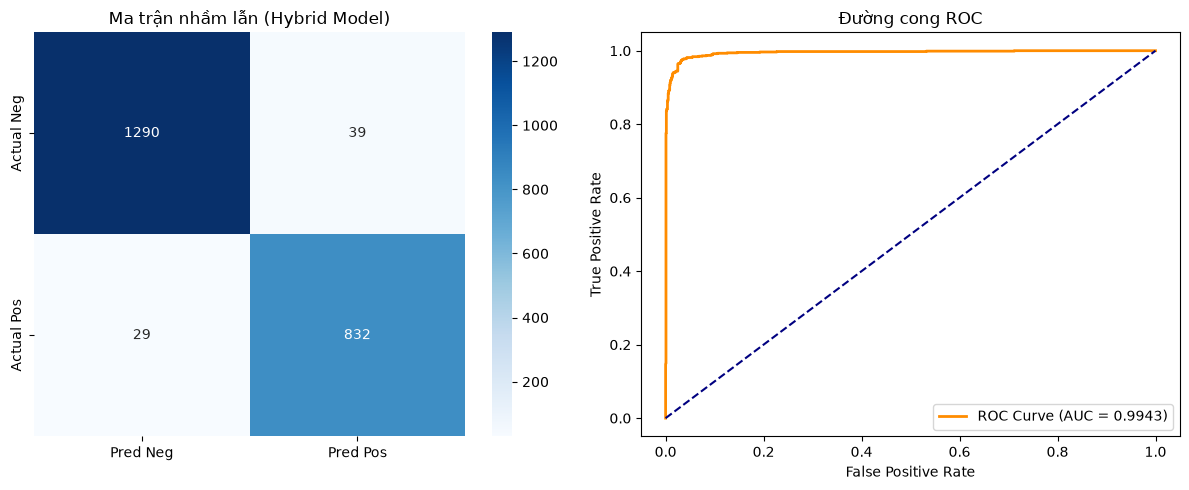

In [7]:
# Load lại model tốt nhất cho Hybrid
hyb_model.load_state_dict(torch.load(MODEL_SAVE_DIR / "phobert_hybrid.pt"))
val_acc, labels, preds = evaluate(hyb_model, test_loader_hyb, device, is_hybrid=True)

print("=== BÁO CÁO HIỆU SUẤT MODEL LAI ===")
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

# Vẽ đồ thị
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=["Pred Neg", "Pred Pos"], yticklabels=["Actual Neg", "Actual Pos"])
axes[0].set_title("Ma trận nhầm lẫn (Hybrid Model)")

# Đồ thị ROC
hyb_model.eval()
all_probs = []
with torch.no_grad():
    for batch in test_loader_hyb:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        metadata = batch["metadata"].to(device)
        logits = hyb_model(input_ids, attention_mask, metadata)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)

fpr, tpr, _ = roc_curve(labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Đường cong ROC')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 7. Dự đoán Thực tế trên Câu văn mới

In [8]:
class SentimentPredictor:
    def __init__(self, model, tokenizer, is_hybrid=True):
        self.model = model
        self.tokenizer = tokenizer
        self.is_hybrid = is_hybrid
        self.device = next(model.parameters()).device
        self.model.eval()
        
    def predict(self, text, rating=5, has_media=1):
        tokens = self.tokenizer(str(text), max_length=128, padding="max_length", truncation=True, return_tensors="pt")
        input_ids = tokens["input_ids"].to(self.device)
        attention_mask = tokens["attention_mask"].to(self.device)
        
        with torch.no_grad():
            if self.is_hybrid:
                # Chuẩn hóa metadata tương tự như khi train
                rating_stars = rating / 5.0
                metadata_tensor = torch.tensor([[rating_stars, float(has_media)]], dtype=torch.float32).to(self.device)
                logits = self.model(input_ids=input_ids, attention_mask=attention_mask, metadata=metadata_tensor)
            else:
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                
            prob = torch.softmax(logits, dim=1)[:, 1].item()
            label = torch.argmax(logits, dim=1).item()
            
        sentiment = "🟢 POSITIVE" if label == 1 else "🔴 NEGATIVE"
        print(f"📝 Văn bản: '{text}'")
        print(f"⭐ Rating: {rating} | 📷 Has Media: {has_media}")
        print(f"📊 Xác suất lớp Positive: {prob*100:.2f}%")
        print(f"🎯 Kết luận: {sentiment}")
        print("-" * 50)

predictor = SentimentPredictor(hyb_model, tokenizer, is_hybrid=True)
predictor.predict("Sản phẩm rất tốt, đóng gói cẩn thận, giao hàng siêu nhanh.", rating=5, has_media=1)
predictor.predict("Hơi thất vọng một chút, sản phẩm bị trầy xước nhẹ khi mở hộp.", rating=2, has_media=0)

📝 Văn bản: 'Sản phẩm rất tốt, đóng gói cẩn thận, giao hàng siêu nhanh.'
⭐ Rating: 5 | 📷 Has Media: 1
📊 Xác suất lớp Positive: 99.32%
🎯 Kết luận: 🟢 POSITIVE
--------------------------------------------------
📝 Văn bản: 'Hơi thất vọng một chút, sản phẩm bị trầy xước nhẹ khi mở hộp.'
⭐ Rating: 2 | 📷 Has Media: 0
📊 Xác suất lớp Positive: 3.92%
🎯 Kết luận: 🔴 NEGATIVE
--------------------------------------------------
